# Human-In-The-Loop Agents

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import MemorySaver

from langgraph.types import interrupt, Command

In [2]:
import os
from typing import TypedDict, Optional

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
def get_groq_llm() -> ChatOpenAI:
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7,
        max_tokens=2000
    )

llm = get_groq_llm()

In [4]:
class PostState(TypedDict):
    info: dict                     # input information for the post (topic, tone, audience, key points, etc)
    draft: str                     # current draft of LinkedIn post
    human_feedback: Optional[str]  # feedback from human reviewer
    approved: bool                 # whether human reviewer approved
    final_post: Optional[str]      # final approved post content


In [5]:
def generate_draft(state: PostState) -> dict:
    info = state["info"]
    # Build prompt based on info
    prompt = f"""
        You are writing a LinkedIn post. Here is the info:
            Topic: {info.get('topic')}
            Key points: {info.get('key_points')}
            Tone: {info.get('tone')}
            Audience: {info.get('audience')}

        Write a LinkedIn-style post (1-2 short paragraphs) with that info.
        """
    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content.strip()
    print("=== AI Generated Draft ===")
    print(draft)
    return {"draft": draft, "approved": False}

In [6]:
def ask_for_feedback(state: PostState) -> dict:
    print("\n--- PAUSING FOR HUMAN REVIEW ---\nDraft to review:\n")
    print(state["draft"])

    # Use interrupt to pause and wait for human input
    feedback = interrupt("Please review the draft. Provide feedback (or type 'approved' if OK):")

    # Determine approval based on exact word (you may refine logic)
    approved = (feedback.strip().lower() == "approved")

    return {"human_feedback": feedback, "approved": approved}

In [7]:
def decide_next(state: PostState) -> str:
    if state.get("approved", False):
        return "approved"
    else:
        return "revise"

In [8]:
def revise_draft(state: PostState) -> dict:
    feedback = state["human_feedback"] or ""
    old_draft = state["draft"]
    prompt = f"""
    You are rewriting a LinkedIn post based on the feedback. Original draft:
    {old_draft}

    Feedback from reviewer:
    {feedback}

    Revise the draft accordingly (keeping same tone and audience) and output the improved post.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    new_draft = response.content.strip()

    print("=== AI Revised Draft ===")
    print(new_draft)

    return {"draft": new_draft, "approved": False}

In [9]:
def post_to_linkedin(state: PostState) -> dict:
    final = state["draft"]

    # Here you would make the real LinkedIn API call.
    # e.g. linkedin_client.post_update(final)
    print("=== POSTING TO LINKEDIN ===")
    print(final)

    # After posting, you can set final_post
    return {"final_post": final}

In [10]:
def build_workflow_graph() -> StateGraph:
    builder = StateGraph(PostState)

    builder.add_node("generate_draft", generate_draft)
    builder.add_node("ask_for_feedback", ask_for_feedback)
    builder.add_node("revise_draft", revise_draft)
    builder.add_node("post_to_linkedin", post_to_linkedin)

    # Define edges
    builder.add_edge(START, "generate_draft")
    # builder.add_edge("generate_draft", "ask_for_feedback")
    # builder.add_conditional_edges('ask_for_feedback', decide_next, {'approved': 'post_to_linkedin', 'needs_improvement': 'revise_draft'})
    # builder.add_edge('revise_draft', 'ask_for_feedback')
    # builder.add_edge("post_to_linkedin", END)

    builder.add_edge("generate_draft", "ask_for_feedback")
    builder.add_conditional_edges(
        "ask_for_feedback",
        decide_next,
        {"approved": "post_to_linkedin", "revise": "revise_draft"}
    )
    builder.add_edge("revise_draft", "ask_for_feedback")
    builder.add_edge("post_to_linkedin", END)

    # Compile with checkpointing to support interrupt/resume
    graph = builder.compile(checkpointer=MemorySaver())
    return graph

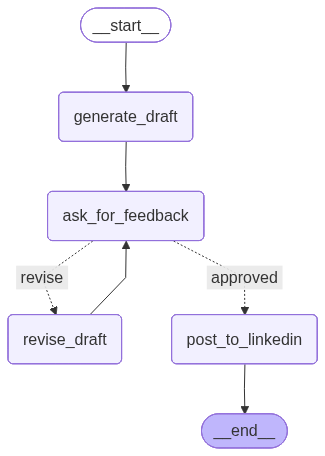

In [11]:
graph= build_workflow_graph()
graph

In [12]:
if __name__ == "__main__":
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = {"configurable": {"thread_id": thread_id}}

    result = graph.invoke(initial_state, config=config)
    # When it hits interrupt (in ask_for_feedback), you'll need to resume manually:
    # For example:
    #   graph.invoke(Command(resume="Looks great, approve"), config=config)
    #
    # In a real UI setup you'd capture human input & call resume programmatically.

    print("\nWorkflow ended. Final state:")
    print(graph.get_state(config))

=== AI Generated Draft ===
🚀 **Automate Your Data Science Workflow with LangGraph**  
As data scientists, we’re constantly juggling data ingestion, feature engineering, model training, and deployment. LangGraph lets us build *agentic workflows* that orchestrate these steps automatically while keeping a **human‑in‑the‑loop** at every critical checkpoint. Think of it as a smart assistant that learns which tasks to hand off, which to pause for your review, and which to trigger next—so you can focus on the insights that matter most.

💡 **Why It Matters for Your LinkedIn Presence**  
When you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed in your posts or portfolio, ensuring your audience sees a clear, repeatable process. By aligning the tool’s voice with your brand—professional yet approachable—you’ll demonstrate both technical rigor and thoughtful collaboration. Let’s keep the conversation flowing, one automated step at a time.

--- PAUSING

In [13]:
print(graph.get_state(config))

StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nAs data scientists, we’re constantly juggling data ingestion, feature engineering, model training, and deployment. LangGraph lets us build *agentic workflows* that orchestrate these steps automatically while keeping a **human‑in‑the‑loop** at every critical checkpoint. Think of it as a smart assistant that learns which tasks to hand off, which to pause for your review, and which to trigger next—so you can focus on the insights that matter most.\n\n💡 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed in your posts or portfolio, ensuring your audie

In [14]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nAs data scientists, we’re constantly juggling data ingestion, feature engineering, model training, and deployment. LangGraph lets us build *agentic workflows* that orchestrate these steps automatically while keeping a **human‑in‑the‑loop** at every critical checkpoint. Think of it as a smart assistant that learns which tasks to hand off, which to pause for your review, and which to trigger next—so you can focus on the insights that matter most.\n\n💡 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed in your posts or portfolio, ensuring your audi

## Manual resume

In [15]:
state = graph.get_state(config)
interrupts = getattr(state, "interrupts", None) or []
print(interrupts)

for intr in interrupts:
    print(f"\nInterrupt ID: {intr.id}\nprompt: {intr.value}")

(Interrupt(value="Please review the draft. Provide feedback (or type 'approved' if OK):", id='c48f13a96336af2397dfc1b679a68e57'),)

Interrupt ID: c48f13a96336af2397dfc1b679a68e57
prompt: Please review the draft. Provide feedback (or type 'approved' if OK):


In [16]:
if not interrupts:
    print("Unexpected: no interrupt was raised for human review.")
else:
    for intr in interrupts:
        print(f"Interrupt ID: {intr.id}, prompt: {intr.value}")

    # Ask human for feedback for every interrupt happened
    human_answer = input("Enter feedback or type ‘approve’: ")

    # Step 3: Resume workflow with human feedback
    result2 = graph.invoke(Command(resume={interrupts[0].id: human_answer}), config=config)
    print("=== After resume with human feedback ===")
    print(graph.get_state(config))



Interrupt ID: c48f13a96336af2397dfc1b679a68e57, prompt: Please review the draft. Provide feedback (or type 'approved' if OK):

--- PAUSING FOR HUMAN REVIEW ---
Draft to review:

🚀 **Automate Your Data Science Workflow with LangGraph**  
As data scientists, we’re constantly juggling data ingestion, feature engineering, model training, and deployment. LangGraph lets us build *agentic workflows* that orchestrate these steps automatically while keeping a **human‑in‑the‑loop** at every critical checkpoint. Think of it as a smart assistant that learns which tasks to hand off, which to pause for your review, and which to trigger next—so you can focus on the insights that matter most.

💡 **Why It Matters for Your LinkedIn Presence**  
When you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed in your posts or portfolio, ensuring your audience sees a clear, repeatable process. By aligning the tool’s voice with your brand—professional yet approachabl

In [17]:
final_state = graph.get_state(config)
print("\n--- Final State Check ---")
print(final_state)



--- Final State Check ---
StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nData science today is a mash‑up of ingestion, feature engineering, model training, and deployment—all happening at the speed of cloud native tech. LangGraph lets you stitch these pieces together into *agentic workflows* that run automatically, but always pause for a human check‑in at the critical moments. Think of it as a smart assistant that learns which tasks to hand off, which to flag for your review, and which to trigger next—so you can focus on the insights that really matter.\n\n🔍 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines t

In [18]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nData science today is a mash‑up of ingestion, feature engineering, model training, and deployment—all happening at the speed of cloud native tech. LangGraph lets you stitch these pieces together into *agentic workflows* that run automatically, but always pause for a human check‑in at the critical moments. Think of it as a smart assistant that learns which tasks to hand off, which to flag for your review, and which to trigger next—so you can focus on the insights that really matter.\n\n🔍 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed right in

In [19]:
# Feedback you got from human
feedback_value = "approved"

# Use the interrupt ID from the snapshot: e.g., "527d0f000978e04a698659d87dddb60d"
resume_command = Command(resume={ "54decab71cdd215a7bf4fcbb311c8bcc": feedback_value })

# Invoke the graph to resume
result = graph.invoke(resume_command, config=config)


--- PAUSING FOR HUMAN REVIEW ---
Draft to review:

🚀 **Automate Your Data Science Workflow with LangGraph**  
Data science today is a mash‑up of ingestion, feature engineering, model training, and deployment—all happening at the speed of cloud native tech. LangGraph lets you stitch these pieces together into *agentic workflows* that run automatically, but always pause for a human check‑in at the critical moments. Think of it as a smart assistant that learns which tasks to hand off, which to flag for your review, and which to trigger next—so you can focus on the insights that really matter.

🔍 **Why It Matters for Your LinkedIn Presence**  
When you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed right into your posts or portfolio. That means your audience sees a clear, repeatable process, not just a set of code snippets. By aligning the tool’s voice with your brand—professional yet approachable—you’ll demonstrate both technical rigor and

In [20]:
state_after = graph.get_state(config)
print("State after resuming:", state_after)


State after resuming: StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nData science today is a mash‑up of ingestion, feature engineering, model training, and deployment—all happening at the speed of cloud native tech. LangGraph lets you stitch these pieces together into *agentic workflows* that run automatically, but always pause for a human check‑in at the critical moments. Think of it as a smart assistant that learns which tasks to hand off, which to flag for your review, and which to trigger next—so you can focus on the insights that really matter.\n\n🔍 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines that y

In [21]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'info': {'topic': 'Data Science Workflow Automation with LangGraph', 'key_points': 'human-in-the-loop, agentic workflow, LinkedIn posts, brand voice', 'tone': 'professional yet friendly', 'audience': 'data scientists and AI practitioners on LinkedIn'}, 'draft': '🚀 **Automate Your Data Science Workflow with LangGraph**  \nData science today is a mash‑up of ingestion, feature engineering, model training, and deployment—all happening at the speed of cloud native tech. LangGraph lets you stitch these pieces together into *agentic workflows* that run automatically, but always pause for a human check‑in at the critical moments. Think of it as a smart assistant that learns which tasks to hand off, which to flag for your review, and which to trigger next—so you can focus on the insights that really matter.\n\n🔍 **Why It Matters for Your LinkedIn Presence**  \nWhen you share your latest experiments, LangGraph can generate reproducible pipelines that you can embed right in

# Automatic Loop Resume

In [22]:
if __name__ == "__main__":
    input_info = {
        "topic": "Data Science Workflow Automation with LangGraph",
        "key_points": "human-in-the-loop, agentic workflow, LinkedIn posts, brand voice",
        "tone": "professional yet friendly",
        "audience": "data scientists and AI practitioners on LinkedIn"
    }

    initial_state: PostState = {
        "info": input_info,
        "draft": "",
        "human_feedback": None,
        "approved": False,
        "final_post": None
    }

    graph = build_workflow_graph()
    thread_id = "linkedin_post_thread_1"
    config = {"configurable": {"thread_id": thread_id}}

    # Invoke the workflow
    graph.invoke(initial_state, config=config)

    # Loop for human input until workflow ends
    while True:
        state = graph.get_state(config)
        interrupts = getattr(state, "interrupts", None) or []
        if not interrupts:
            # Workflow done
            break

        for intr in interrupts:
            prompt = intr.value if hasattr(intr, "value") else str(intr)
            print(f"\n[Interrupt prompt] {prompt}")
            answer = input("Your answer: ")
            graph.invoke(Command(resume={intr.id: answer}), config=config)

    # Final state
    final_state = graph.get_state(config)
    print("\nWorkflow completed. Final state:")
    print(final_state)

=== AI Generated Draft ===
🚀 **Automating the Data Science Workflow with LangGraph**  
In a world where data scientists juggle countless steps—from feature engineering to model deployment—LangGraph is turning the tide by letting you build *agentic workflows* that think and act on your behalf. But it doesn’t replace you; it keeps a *human‑in‑the‑loop* at every critical decision point. This means you can focus on strategy while the framework handles the repetitive tasks, all while staying in control of the final output.

💡 Whether you’re drafting a post, preparing a demo, or fine‑tuning a model, LangGraph’s modular approach lets you plug in your own logic, monitor progress in real time, and iterate faster than ever. If you’re a data scientist or AI practitioner looking to scale your experiments without sacrificing quality, this is the tool that keeps you at the helm—while the agents do the heavy lifting. Let’s chat about how you can start building smarter, more resilient pipelines today!